In [1]:
# import necessary libraries:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import os

In [ ]:
# run code from data_input folder:
os.chdir('C:/Users/ccwis/OneDrive/Documents/1. MEng - Data Science/data_input')

In [3]:
data = pd.read_csv("factor_returns.csv", parse_dates=['Date'])
data = data.set_index('Date')

#df_benchmark = pd.read_csv("benchmark_returns.csv", parse_dates=['Date'])
#df_benchmark = df_benchmark.set_index('Date')

#data = pd.concat([df_benchmark,df_factors], axis=1, join='inner')
data = data.dropna()

In [4]:
print(data)

            Momentum     Value   Quality
Date                                    
2007-03-05  0.018613  0.015753 -0.010966
2007-03-12 -0.012887 -0.020257  0.048512
2007-03-19  0.060268  0.052751  0.014917
2007-03-26  0.022670  0.007935  0.007713
2007-04-02  0.010079  0.009888  0.018702
...              ...       ...       ...
2025-03-03  0.049395  0.011621  0.076581
2025-03-10 -0.009996 -0.002634  0.041062
2025-03-17  0.040341  0.006385  0.018397
2025-03-24  0.008068 -0.006651  0.020056
2025-03-31 -0.017642 -0.096445 -0.010625

[944 rows x 3 columns]


In [5]:
# List of factor columns and the benchmark
cols = ['Momentum', 'Value', 'Quality']

# Compute cumulative returns for each column
cum_returns = (1 + data[cols]).cumprod() - 1

# Optional: format as percentages
#cum_returns = cum_returns * 100

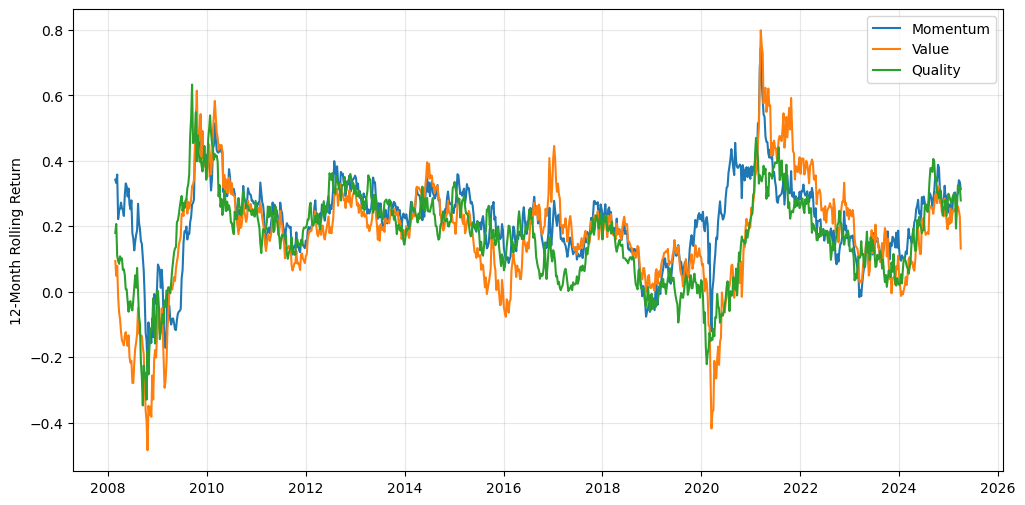

In [6]:
rolling_12m = data[cols].rolling(52).sum()  # 52 weeks

plt.figure(figsize=(12,6))
plt.plot(rolling_12m.index, rolling_12m)
#plt.title("12-Month Rolling Factor Risk Premia")
plt.ylabel("12-Month Rolling Return")
plt.legend(cols)
plt.grid(True, alpha=0.3)
plt.show()

XGBOOST:

In [7]:
import pandas as pd
import numpy as np

# =========================================================
# 0. HELPER FUNCTIONS
# =========================================================

def compute_strength_scores(row):
    """Bradley–Terry strength scoring."""
    p_MV = row["p_M_gt_V"]
    p_MQ = row["p_M_gt_Q"]
    p_VQ = row["p_V_gt_Q"]

    Momentum  =  p_MV + p_MQ
    Value     = -(1 - p_MV) + p_VQ
    Quality   = -(1 - p_MQ) -(1 - p_VQ)

    return pd.Series([Momentum, Value, Quality],
                     index=["Momentum_score", "Value_score", "Quality_score"])


def softmax_weights(row):
    """Softmax over scores."""
    x = row[["Momentum_score","Value_score","Quality_score"]].values
    e = np.exp(x - np.max(x))
    w = e / e.sum()
    return pd.Series(w, index=["Momentum_w","Value_w","Quality_w"])


def build_portfolio(weights_raw, name, factor_ret):
    """
    Build a portfolio for weekly or monthly weights:
    - Lag weights
    - Merge w/ returns
    - Compute return, Sharpe, turnover
    """
    weights_lagged = weights_raw.shift(1)

    df_port = factor_ret.join(weights_lagged, how="inner").dropna()

    df_port[f"{name}_return"] = (
          df_port["Momentum"] * df_port["Momentum_w"]
        + df_port["Value"]    * df_port["Value_w"]
        + df_port["Quality"]  * df_port["Quality_w"]
    )

    # cumulative returns
    df_port[f"{name}_cumret"] = (1 + df_port[f"{name}_return"]).cumprod() - 1

    # Sharpe
    mu = df_port[f"{name}_return"].mean()
    sigma = df_port[f"{name}_return"].std()
    sharpe = (mu / sigma) * np.sqrt(52)
    

    # turnover
    df_port[f"{name}_turnover"] = (
        df_port[["Momentum_w","Value_w","Quality_w"]]
        .diff().abs().sum(axis=1) / 2
    )

    avg_wk = df_port[f"{name}_turnover"].mean()
    annual_turnover = avg_wk * 52

    return {
        "Model": "XGBoost",
        "Rebalance": name.capitalize(),
        "Sharpe": sharpe,
        "Cumulative Return": df_port[f"{name}_cumret"].iloc[-1],
        "Avg Weekly Turnover": avg_wk,
        "Annual Turnover": annual_turnover
    }, df_port


# =========================================================
# 1. LOAD XGBOOST PROBABILITIES
# =========================================================

xmv = pd.read_csv("momentum_value_probs.csv",    parse_dates=["Date"]).set_index("Date")
xmq = pd.read_csv("momentum_quality_probs.csv", parse_dates=["Date"]).set_index("Date")
xvq = pd.read_csv("xgb_value_quality_probs.csv",parse_dates=["Date"]).set_index("Date")

xmv = xmv.rename(columns={"probability":"p_M_gt_V"})
xmq = xmq.rename(columns={"probability":"p_M_gt_Q"})
xvq = xvq.rename(columns={"probability":"p_V_gt_Q"})

df_xgb_probs = xmv[["p_M_gt_V"]].join(
    [xmq[["p_M_gt_Q"]], xvq[["p_V_gt_Q"]]],
    how="inner"
)


# =========================================================
# 2. SCORES + WEEKLY SOFTMAX
# =========================================================

xgb_scores = df_xgb_probs.apply(compute_strength_scores, axis=1)
xgb_weights_weekly = xgb_scores.apply(softmax_weights, axis=1)


# =========================================================
# 3. MONTHLY REBALANCE (BME)
# =========================================================

xgb_weights_monthly = xgb_weights_weekly.resample("BME").last()
xgb_weights_monthly_ffill = (
    xgb_weights_monthly.reindex(xgb_weights_weekly.index)
    .ffill()
)


# =========================================================
# 4. FACTOR RETURNS
# =========================================================

factor_ret = pd.read_csv("factor_returns.csv", parse_dates=["Date"]).set_index("Date")


# =========================================================
# 5. BUILD BOTH PORTFOLIOS (WEEKLY & MONTHLY)
# =========================================================

metrics_monthly, df_xgb_monthly = build_portfolio(
    xgb_weights_monthly_ffill,
    "monthly",
    factor_ret
)

metrics_weekly, df_xgb_weekly = build_portfolio(
    xgb_weights_weekly,
    "weekly",
    factor_ret
)


# =========================================================
# 6. COMPARISON TABLE
# =========================================================
    
comparison_xgb = pd.DataFrame([
    metrics_monthly,
    metrics_weekly
])[[
    "Model","Rebalance","Sharpe","Cumulative Return","Avg Weekly Turnover","Annual Turnover"
]]

print("\n====================== XGBOOST REBALANCE COMPARISON ======================\n")
print(comparison_xgb.to_string(index=False))
print("\n==========================================================================\n")



====================== XGBOOST REBALANCE COMPARISON ======================

  Model Rebalance   Sharpe  Cumulative Return  Avg Weekly Turnover  Annual Turnover
XGBoost   Monthly 0.965481           0.160831             0.001598         0.083096
XGBoost    Weekly 0.418137           0.101051             0.084249         4.380937




In [8]:
# =========================================================
# PAIRWISE FACTOR PORTFOLIOS (Momentum–Value, Momentum–Quality, Value–Quality)
# WITH ANNUALIZED RETURNS
# =========================================================

def build_pairwise_portfolio(signal, ret_long, ret_short, name):
    """
    Builds a pairwise long-short portfolio:
        signal = 1 → long ret_long, short ret_short
        signal = 0 → long ret_short, short ret_long

    Computes:
      - weekly return
      - annualized Sharpe
      - annualized return
      - cumulative return
      - weekly turnover
      - monthly turnover (calendar month average)
      - annual turnover
    """

    # Lag signal to avoid look-ahead
    sig = signal.shift(1).dropna()

    # Merge data
    df = pd.concat([sig, ret_long, ret_short], axis=1).dropna()
    df.columns = ["signal", "ret_long", "ret_short"]

    # Weekly long-short return
    df[f"{name}_return"] = (
        df["signal"] * df["ret_long"] +
        (1 - df["signal"]) * df["ret_short"]
    )

    # Cumulative return
    df[f"{name}_cumret"] = (1 + df[f"{name}_return"]).cumprod() - 1

    # Weekly mean & std
    mu = df[f"{name}_return"].mean()
    sigma = df[f"{name}_return"].std()

    # Annualized Sharpe
    sharpe = (mu / sigma) * np.sqrt(52)

    # Annualized return
    annualized_return = (1 + mu)**52 - 1

    # Weekly turnover (signal changes)
    df[f"{name}_turnover"] = df["signal"].diff().abs().fillna(0)

    avg_weekly_turnover = df[f"{name}_turnover"].mean()
    annual_turnover = avg_weekly_turnover * 52

    # === MONTHLY TURNOVER (calendar-month avg of weekly turnover) ===
    monthly_turnover = avg_weekly_turnover*4

    return {
        "Pair": name,
        "Sharpe": sharpe,
        "Annualized Return": annualized_return,
        "Cumulative Return": df[f"{name}_cumret"].iloc[-1],
        "Avg Weekly Turnover": avg_weekly_turnover,
        "Monthly Turnover": monthly_turnover,
        "Annual Turnover": annual_turnover
    }, df
# =========================================================
# BUILD PAIRWISE SIGNALS
# =========================================================

sig_MV = (xmv["p_M_gt_V"] > 0.5).astype(int)
sig_MQ = (xmq["p_M_gt_Q"] > 0.5).astype(int)
sig_VQ = (xvq["p_V_gt_Q"] > 0.5).astype(int)


# =========================================================
# APPLY PORTFOLIO BUILDER PER PAIR
# =========================================================

mv_metrics, df_mv = build_pairwise_portfolio(
    sig_MV, factor_ret["Momentum"], factor_ret["Value"], "Momentum_vs_Value"
)

mq_metrics, df_mq = build_pairwise_portfolio(
    sig_MQ, factor_ret["Momentum"], factor_ret["Quality"], "Momentum_vs_Quality"
)

vq_metrics, df_vq = build_pairwise_portfolio(
    sig_VQ, factor_ret["Value"], factor_ret["Quality"], "Value_vs_Quality"
)


# =========================================================
# COMPARISON TABLE
# =========================================================

pairwise_comparison = pd.DataFrame([
    mv_metrics,
    mq_metrics,
    vq_metrics
])[[
    "Pair","Sharpe","Annualized Return","Cumulative Return",
    "Avg Weekly Turnover","Monthly Turnover","Annual Turnover"
]]

print("\n====================== PAIRWISE FACTOR PORTFOLIOS ======================\n")
print(pairwise_comparison.to_string(index=False))
print("\n========================================================================\n")



====================== PAIRWISE FACTOR PORTFOLIOS ======================

               Pair   Sharpe  Annualized Return  Cumulative Return  Avg Weekly Turnover  Monthly Turnover  Annual Turnover
  Momentum_vs_Value 1.551882           0.300239           1.096316             0.212903          0.851613        11.070968
Momentum_vs_Quality 2.433969           0.465712           2.013864             0.329032          1.316129        17.109677
   Value_vs_Quality 2.262809           0.446989           1.891822             0.367742          1.470968        19.122581


